# HUẤN LUYỆN CÁC MÔ HÌNH VÀ ĐÁNH GIÁ KẾT QUẢ

## 1. Nạp dữ liệu từ Preprocessing_data

In [ ]:
# Thực hiện chạy toàn bộ mã trong file preprocessing_data.ipynb
# Tất cả dữ liệu và biến trong file đó sẽ được tải vào môi trường hiện tại

%run preprocessing_data.ipynb

## 2. Thiết lập môi trường

### a) Import thư viện

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

### b) Chuẩn bị các mô hình

In [27]:
# Tạo một dictionary chứa các mô hình
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression (Softmax)": LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
}

#Tạo một danh sách các dictionary, mỗi dictionary đại diện cho một thí nghiệm ứng với cách chia tỉ lệ dữ liệu và loại dữ liệu khác nhau
experiments = [
    #Dữ liệu HOG gốc
    {
        "name": "HOG Gốc - Tỉ lệ 4:1",
        "X_train": X_train_hog_41, "y_train": y_train_hog_41,
        "X_val": X_val_hog_41, "y_val": y_val_hog_41
    },
    {
        "name": "HOG Gốc - Tỉ lệ 7:3",
        "X_train": X_train_hog_73, "y_train": y_train_hog_73,
        "X_val": X_val_hog_73, "y_val": y_val_hog_73
    },
    {
        "name": "HOG Gốc - Tỉ lệ 6:4",
        "X_train": X_train_hog_64, "y_train": y_train_hog_64,
        "X_val": X_val_hog_64, "y_val": y_val_hog_64
    },
    #Dữ liệu sau khi giảm chiều bằng PCA
    {
        "name": "Sau PCA - Tỉ lệ 4:1",
        "X_train": X_train_41_pca, "y_train": Y_train_41_pca,
        "X_val": X_val_41_pca, "y_val": Y_val_41_pca
    },
    {
        "name": "Sau PCA - Tỉ lệ 7:3",
        "X_train": X_train_73_pca, "y_train": Y_train_73_pca,
        "X_val": X_val_73_pca, "y_val": Y_val_73_pca
    },
    {
        "name": "Sau PCA - Tỉ lệ 6:4",
        "X_train": X_train_64_pca, "y_train": Y_train_64_pca,
        "X_val": X_val_64_pca, "y_val": Y_val_64_pca
    },
    #Dữ liệu sau khi giảm chiều bằng LDA
    {
        "name": "Sau LDA - Tỉ lệ 4:1",
        "X_train": X_train_41_lda, "y_train": Y_train_41_lda,
        "X_val": X_val_41_lda, "y_val": Y_val_41_lda
    },
    {
        "name": "Sau LDA - Tỉ lệ 7:3",
        "X_train": X_train_73_lda, "y_train": Y_train_73_lda,
        "X_val": X_val_73_lda, "y_val": Y_val_73_lda
    },
    {
        "name": "Sau LDA - Tỉ lệ 6:4",
        "X_train": X_train_64_lda, "y_train": Y_train_64_lda,
        "X_val": X_val_64_lda, "y_val": Y_val_64_lda
    },
]

#Nơi lưu trữ kết quả
results_list = []

print("Đã sẵn sàng chạy các mô hình...\n")

Đã sẵn sàng chạy các mô hình...



## 3. Huấn luyện và đánh giá các mô hình

In [36]:
print("BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN VÀ ĐÁNH GIÁ\n" + "="*50)

#Lặp qua từng thí nghiệm
for exp in experiments:
    print(f"\n--- Thí nghiệm: {exp['name']} ---")
    
    #Lấy dữ liệu từ dictionary của thí nghiệm
    X_train_sub, y_train_sub = exp['X_train'], exp['y_train']
    X_val, y_val = exp['X_val'], exp['y_val']

    #Lặp qua từng mô hình
    for m_name, model in models.items():
        #Huấn luyện mô hình trên tập train_sub
        model.fit(X_train_sub, y_train_sub)

        #Dự đoán trên cả tập train và validation để so sánh
        y_train_pred = model.predict(X_train_sub)
        y_val_pred = model.predict(X_val)

        #Tính toán độ chính xác
        train_accuracy = accuracy_score(y_train_sub, y_train_pred)
        val_accuracy = accuracy_score(y_val, y_val_pred)

        #Lưu kết quả vào danh sách kết quả
        results_list.append({
            "Thí nghiệm": exp['name'],
            "Mô hình": m_name,
            "Accuracy (Train)": train_accuracy,
            "Accuracy (Validation)": val_accuracy
        })

print("\n" + "="*50 + "\nQUÁ TRÌNH HUẤN LUYỆN VÀ ĐÁNH GIÁ ĐÃ HOÀN TẤT!")

BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN VÀ ĐÁNH GIÁ

--- Thí nghiệm: HOG Gốc - Tỉ lệ 4:1 ---

--- Thí nghiệm: HOG Gốc - Tỉ lệ 7:3 ---

--- Thí nghiệm: HOG Gốc - Tỉ lệ 6:4 ---

--- Thí nghiệm: Sau PCA - Tỉ lệ 4:1 ---

--- Thí nghiệm: Sau PCA - Tỉ lệ 7:3 ---

--- Thí nghiệm: Sau PCA - Tỉ lệ 6:4 ---

--- Thí nghiệm: Sau LDA - Tỉ lệ 4:1 ---

--- Thí nghiệm: Sau LDA - Tỉ lệ 7:3 ---

--- Thí nghiệm: Sau LDA - Tỉ lệ 6:4 ---

QUÁ TRÌNH HUẤN LUYỆN VÀ ĐÁNH GIÁ ĐÃ HOÀN TẤT!


## 4. Tổng hợp kết quả

In [29]:
results_df = pd.DataFrame(results_list)


split_data = results_df['Thí nghiệm'].str.split(' - Tỉ lệ ', expand=True)
results_df['Loại dữ liệu'] = split_data[0]
results_df['Tỉ lệ chia'] = split_data[1]


#Bảng so sánh hiệu suất chính (chỉ trên tập Validation)
pivot_df = results_df.pivot_table(
    index=['Tỉ lệ chia', 'Loại dữ liệu'],
    columns='Mô hình',
    values='Accuracy (Validation)'
)

# Định dạng lại các số trong bảng để hiển thị 4 chữ số thập phân
formatted_pivot = pivot_df.applymap('{:.4f}'.format)

print("BẢNG 1: SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH TRÊN TẬP VALIDATION")
print("="*85)
print(formatted_pivot)
print("\n" + "="*85)


#Bảng đầy đủ để phân tích Overfitting
#Tính toán độ chênh lệch giữa accuracy của tập train và validation
results_df['Chênh lệch (Train-Val)'] = results_df['Accuracy (Train)'] - results_df['Accuracy (Validation)']

sorted_df = results_df.sort_values(by=['Tỉ lệ chia', 'Loại dữ liệu'])

print("\nBẢNG 2: DỮ LIỆU ĐẦY ĐỦ ĐỂ PHÂN TÍCH OVERFITTING")
print("="*85)
print(sorted_df[[
    "Tỉ lệ chia",
    "Loại dữ liệu",
    "Mô hình",
    "Accuracy (Train)",
    "Accuracy (Validation)",
    "Chênh lệch (Train-Val)"
]].to_string())

BẢNG 1: SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH TRÊN TẬP VALIDATION
Mô hình                 Logistic Regression (Softmax) Naive Bayes
Tỉ lệ chia Loại dữ liệu                                          
4:1        HOG Gốc                             0.8355      0.6439
           Sau LDA                             0.6605      0.6509
           Sau PCA                             0.8031      0.4768
6:4        HOG Gốc                             0.8319      0.6389
           Sau LDA                             0.7186      0.7282
           Sau PCA                             0.8166      0.4394
7:3        HOG Gốc                             0.8378      0.6412
           Sau LDA                             0.6144      0.5957
           Sau PCA                             0.8221      0.4685


BẢNG 2: DỮ LIỆU ĐẦY ĐỦ ĐỂ PHÂN TÍCH OVERFITTING
   Tỉ lệ chia Loại dữ liệu                        Mô hình  Accuracy (Train)  Accuracy (Validation)  Chênh lệch (Train-Val)
0         4:1      HOG Gốc                 

## 5. Huấn luyện và dự đoán bằng toàn bộ dữ liệu

In [30]:
# Tạo một dictionary chứa các dữ liệu cần thiết
final_datasets = {
    "HOG Gốc": (X_train_hog, X_test_hog),
    "Sau PCA": (X_train_pca, X_test_pca),
    "Sau LDA": (X_train_lda, X_test_lda)
}

# Tạo một dictionary chứa các mô hình
final_models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression (Softmax)": LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
}

# Chuẩn bị nơi lưu kết quả cuối cùng
final_results_list = []
class_names = label_encoder.classes_

print("\nBẮT ĐẦU QUÁ TRÌNH ĐÁNH GIÁ TRÊN TOÀN BỘ TẬP DỮ LIỆU")
print("="*60)

#Lặp qua các loại dữ liệu và mô hình
for data_name, (X_train, X_test) in final_datasets.items():
    print(f"\n---------- Đang xử lý trên dữ liệu: {data_name} ----------")
    for model_name, model in final_models.items():
        print(f"\n>>>>> Mô hình: {model_name} <<<<<")
        
        # Huấn luyện mô hình trên bộ dữ liệu train tương ứng
        model.fit(X_train, y_train_encoded)
        
        # Dự đoán trên tập test tương ứng
        y_test_pred = model.predict(X_test)
        y_train_pred = model.predict(X_train)
        
        # Tính toán và in kết quả
        accuracy = accuracy_score(y_test_encoded, y_test_pred)
        report = classification_report(y_test_encoded, y_test_pred, target_names=class_names, zero_division=0)

        accuracy_train = accuracy_score(y_train_encoded, y_train_pred)
        print(f"Độ chính xác tổng thể trên tập Train: {accuracy_train:.4f}")
        print(f"Độ chính xác tổng thể trên tập Test: {accuracy:.4f}")
        
        print(f"Chênh lệch độ chính xác (Train - Test): {accuracy_train - accuracy:.4f}")
        
        print("Báo cáo phân loại chi tiết:")
        print(report)
        
        # Lưu kết quả vào danh sách
        final_results_list.append({
            "Loại dữ liệu": data_name,
            "Mô hình": model_name,
            "Test Accuracy": accuracy
        })

#Tổng hợp và in bảng kết quả
print("\n" + "="*60)
print("BẢNG TÓM TẮT KẾT QUẢ CUỐI CÙNG")
print("="*60)

final_results_df = pd.DataFrame(final_results_list)
pivot_final = final_results_df.pivot_table(
    index='Loại dữ liệu',
    columns='Mô hình',
    values='Test Accuracy'
)
print(pivot_final.applymap('{:.4f}'.format))


BẮT ĐẦU QUÁ TRÌNH ĐÁNH GIÁ TRÊN TOÀN BỘ TẬP DỮ LIỆU

---------- Đang xử lý trên dữ liệu: HOG Gốc ----------

>>>>> Mô hình: Naive Bayes <<<<<
Độ chính xác tổng thể trên tập Train: 0.6717
Độ chính xác tổng thể trên tập Test: 0.6171
Chênh lệch độ chính xác (Train - Test): 0.0547
Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

      glioma       0.50      0.57      0.53       300
  meningioma       0.46      0.48      0.47       306
     notumor       0.80      0.76      0.78       405
   pituitary       0.68      0.62      0.65       300

    accuracy                           0.62      1311
   macro avg       0.61      0.61      0.61      1311
weighted avg       0.63      0.62      0.62      1311


>>>>> Mô hình: Logistic Regression (Softmax) <<<<<
Độ chính xác tổng thể trên tập Train: 1.0000
Độ chính xác tổng thể trên tập Test: 0.8635
Chênh lệch độ chính xác (Train - Test): 0.1365
Báo cáo phân loại chi tiết:
              precision    recall  f1-scor

## 6. Thêm siêu tham số để giảm overfitting

Lựa chọn mô hình Logistic Regression trên dữ liệu PCA để thực hiện thêm siêu tham số giúp giảm overfiting  

Sau quá trình điều chỉnh, tham số tốt nhất được lựa chọn là C = 0.003

In [ ]:

print("--- THÊM THAM SỐ ĐỂ GIẢM OVERFITTING ---")
print("="*70)

#Lựa chọn siêu tham số cho mô hình để giảm overfitting
print("Mô hình: Logistic Regression (C=0.003) trên dữ liệu PCA.")
champion_model = LogisticRegression(
    multi_class='multinomial', 
    solver='lbfgs', 
    C=0.003,  #Siêu tham số
    max_iter=1000, 
    random_state=42
)

#Huấn luyện mô hình
champion_model.fit(X_train_pca, y_train_encoded)

#Dự đoán và đánh giá trên tập Test
y_test_pred = champion_model.predict(X_test_pca)
y_train_pred = champion_model.predict(X_train_pca)

# 4. In kết quả cuối cùng
print("\n--- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG ---")
test_accuracy = accuracy_score(y_test_encoded, y_test_pred)
train_accuracy = accuracy_score(y_train_encoded, y_train_pred)
print(f"Độ chính xác tổng thể trên tập Train: {train_accuracy:.4f} ({train_accuracy:.2%})")
print(f"Độ chính xác tổng thể trên tập Test: {test_accuracy:.4f} ({test_accuracy:.2%})")
print(f"Chênh lệch độ chính xác (Train - Test): {train_accuracy - test_accuracy:.4f}")

class_names = label_encoder.classes_
print("\nBáo cáo phân loại chi tiết (Classification Report):")
print(classification_report(y_test_encoded, y_test_pred, target_names=class_names, zero_division=0))

--- THÊM THAM SỐ ĐỂ GIẢM OVERFITTING ---
Mô hình: Logistic Regression (C=0.01) trên dữ liệu PCA.

--- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG ---
Độ chính xác tổng thể trên tập Train: 0.9884 (98.84%)
Độ chính xác tổng thể trên tập Test: 0.8596 (85.96%)
Chênh lệch độ chính xác (Train - Test): 0.1288

Báo cáo phân loại chi tiết (Classification Report):
              precision    recall  f1-score   support

      glioma       0.80      0.72      0.76       300
  meningioma       0.75      0.80      0.77       306
     notumor       0.97      0.99      0.98       405
   pituitary       0.88      0.89      0.88       300

    accuracy                           0.86      1311
   macro avg       0.85      0.85      0.85      1311
weighted avg       0.86      0.86      0.86      1311



Có thể thấy, sau khi thêm tham số, mức độ overfiting đã giảm xuống một chút, chênh lệch accuracy giữa tập train và tập test giảm từ 0.1640 xuống còn 0.1288. Độ chính xác tổng thể tăng từ xấp xỉ 0.84 lên xấp xỉ 0.86

## Trực quan hóa và đánh giá tương quan giữa dự đoán – thực tế.

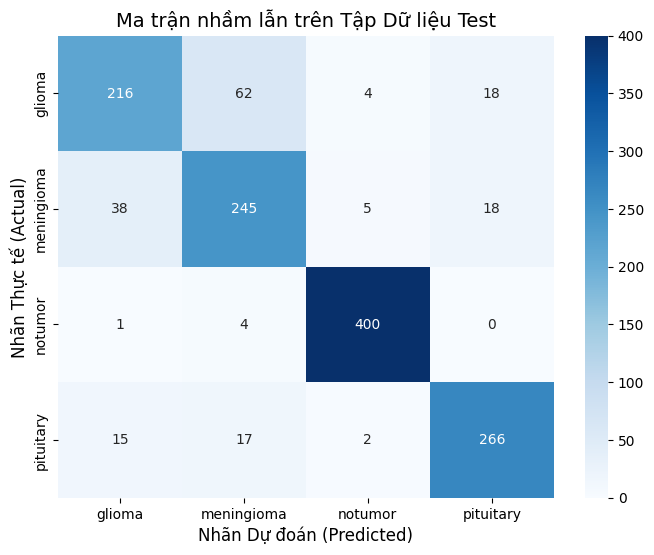

In [46]:
#Tính toán ma trận nhầm lẫn
cm = confusion_matrix(y_test_encoded, y_test_pred)

# Lấy tên của các lớp để hiển thị trên biểu đồ
class_names = label_encoder.classes_

#Vẽ ma trận dưới dạng heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)

# Thêm tiêu đề và nhãn cho các trục
plt.title('Ma trận nhầm lẫn trên Tập Dữ liệu Test', fontsize=14)
plt.ylabel('Nhãn Thực tế (Actual)', fontsize=12)
plt.xlabel('Nhãn Dự đoán (Predicted)', fontsize=12)
plt.show()

### Phân Tích Ma Trận Nhầm Lẫn

---

#### Điểm Mạnh (Các ô trên đường chéo chính)

1. **Nhận diện lớp _notumor_ gần như hoàn hảo**
   - Mô hình dự đoán đúng **400/405** trường hợp → **98,8%**
   - Chỉ nhầm:
     - 5 ca *meningioma* → *notumor*
     - 2 ca *pituitary* → *notumor*
     - 4 ca *glioma* → *notumor*
   - Điều này cho thấy tỷ lệ *âm tính giả* cực thấp — **rất quan trọng trong chẩn đoán y tế**.

2. **Phân loại _pituitary_ rất tốt**
   - Dự đoán đúng **266/300** → **88,7%**
   - Là lớp mô hình phân loại tốt thứ hai.

3. **Phân loại _glioma_ và _meningioma_ ở mức khá**
   - *Meningioma*: **245/306** → **80,1%**
   - *Glioma*: **216/300** → **72,0%**
   - Glioma vẫn là lớp khó nhất

---

#### Điểm Yếu (Các ô ngoài đường chéo – Sự nhầm lẫn)

1. **Nhầm lẫn lớn giữa glioma và meningioma**
   - **62** ca glioma → dự đoán thành meningioma
   - **38** ca meningioma → dự đoán thành glioma  
   ➜ Mô hình gặp khó khăn với 2 lớp này

2. **Nhầm lẫn nhỏ hơn giữa các cặp khác**
   - pituitary ↔ meningioma: **17** và **18** ca
   - pituitary ↔ glioma: **15** và **18** ca

## 8. Đánh giá việc sử dụng mô hình & Giải thích nhận định  
    1. Việc sử dụng mô hình này có phù hợp không?  
**CÓ, KHÁ PHÙ HỢP**. Với độ chính xác tổng thể khoảng 85%, mô hình là chấp nhận được.  
- Độ tin cậy cao ở khía cạnh quan trọng nhất: Xác định gần như tuyệt đối các trường hợp không có khối u.  
- Khả năng phân loại tốt: Các chỉ số Precision, Recall, và F1-score cho tất cả các lớp khối u đều từ 0.75 trở lên, cho thấy mô hình có sự cân bằng tốt giữa việc không bỏ sót và không chẩn đoán nhầm.  

## 9. Đưa bài toán về dạng bài toán hồi quy

In [33]:
#Chuẩn bị dữ liệu cho bài toán hồi quy

#Chọn lớp mục tiêu
TARGET_CLASS = 'pituitary'
print(f"Lớp được chọn làm mục tiêu hồi quy: '{TARGET_CLASS}'")

#Tìm index của lớp mục tiêu trong bộ mã hóa
target_class_index = np.where(label_encoder.classes_ == TARGET_CLASS)[0][0]
print(f"Index của lớp '{TARGET_CLASS}' là: {target_class_index}")

#Huấn luyện một mô hình phân loại để lấy xác suất softmax
#Dùng mô hình Logistic Regression trên dữ liệu HOG gốc
print("\nHuấn luyện mô hình phân loại tạm thời để lấy xác suất softmax...")
softmax_generator_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
softmax_generator_model.fit(X_train_hog, y_train_encoded)

#Tạo ra nhãn hồi quy (regression labels)
#Dùng predict_proba để lấy vector xác suất cho mỗi ảnh
train_probabilities = softmax_generator_model.predict_proba(X_train_hog)
test_probabilities = softmax_generator_model.predict_proba(X_test_hog)

#Nhãn hồi quy chính là xác suất của lớp mục tiêu
y_train_reg = train_probabilities[:, target_class_index]
y_test_reg = test_probabilities[:, target_class_index]

print(f"\nĐã tạo xong dữ liệu hồi quy.")
print(f"Kích thước y_train_reg: {y_train_reg.shape}")
print(f"Kích thước y_test_reg: {y_test_reg.shape}")
print(f"Ví dụ 5 giá trị đầu tiên của y_train_reg: {y_train_reg[:5]}")

Lớp được chọn làm mục tiêu hồi quy: 'pituitary'
Index của lớp 'pituitary' là: 3

Huấn luyện mô hình phân loại tạm thời để lấy xác suất softmax...

Đã tạo xong dữ liệu hồi quy.
Kích thước y_train_reg: (5712,)
Kích thước y_test_reg: (1311,)
Ví dụ 5 giá trị đầu tiên của y_train_reg: [1.23877672e-03 1.64838628e-02 4.89482383e-07 3.17150621e-03
 4.79226832e-02]


In [34]:
#Tạo một dictionary chứa các mô hình hồi quy
regression_models = {
    "Hồi quy Tuyến tính": LinearRegression(),
    #hidden_layer_sizes=(100,): Một lớp ẩn với 100 neuron.
    #max_iter=500: Tăng số vòng lặp để đảm bảo mô hình hội tụ.
    #early_stopping=True: Một kỹ thuật chống overfitting.
    "Multi-Layer Perceptron": MLPRegressor(hidden_layer_sizes=(100,), 
                                           max_iter=500,
                                           random_state=42,
                                           early_stopping=True)
}

#Chuẩn bị các bộ dữ liệu
X_train_original = X_train_hog
X_test_original = X_test_hog

#Dữ liệu giảm về còn 1/3 số chiều bằng PCA
original_dims = X_train_hog.shape[1]
reduced_dims = original_dims // 3
print(f"\nSố chiều dữ liệu HOG gốc: {original_dims}")
print(f"Số chiều sau khi giảm (1/3): {reduced_dims}")

scaler_reg = StandardScaler()
pca_reg = PCA(n_components=reduced_dims)

#Fit trên train, transform trên  test
X_train_scaled_reg = scaler_reg.fit_transform(X_train_hog)
X_test_scaled_reg = scaler_reg.transform(X_test_hog)

X_train_reduced = pca_reg.fit_transform(X_train_scaled_reg)
X_test_reduced = pca_reg.transform(X_test_scaled_reg)

#Tạo một dictionary chứa các loại dữ liệu
regression_datasets = {
    "Dữ liệu HOG nguyên bản": (X_train_original, X_test_original),
    "Dữ liệu Giảm chiều (1/3)": (X_train_reduced, X_test_reduced)
}


Số chiều dữ liệu HOG gốc: 8100
Số chiều sau khi giảm (1/3): 2700


In [35]:
#Chạy thí nghiệm hồi quy
regression_results = []
print("\nBẮT ĐẦU THÍ NGHIỆM HỒI QUY")
print("="*60)

#Lặp qua các loại dữ liệu và mô hình
for data_name, (X_train, X_test) in regression_datasets.items():
    print(f"\n--- Đang xử lý trên: {data_name} ---")
    for model_name, model in regression_models.items():
        # Huấn luyện mô hình
        model.fit(X_train, y_train_reg)
        
        # Dự đoán trên tập test
        y_pred_reg = model.predict(X_test)
        
        # Đánh giá kết quả
        mse = mean_squared_error(y_test_reg, y_pred_reg)
        r2 = r2_score(y_test_reg, y_pred_reg)
        
        print(f"  - Mô hình: {model_name}")
        print(f"    - Mean Squared Error (MSE): {mse:.6f}")
        print(f"    - R-squared (R²):           {r2:.6f}")
        
        regression_results.append({
            "Dữ liệu đầu vào": data_name,
            "Mô hình hồi quy": model_name,
            "MSE": mse,
            "R-squared (R²)": r2
        })

#Hiển thị bảng kết quả tổng hợp
print("\n" + "="*60)
print("BẢNG TỔNG HỢP KẾT QUẢ HỒI QUY")
print("="*60)
results_df_reg = pd.DataFrame(regression_results)
print(results_df_reg.to_string())


BẮT ĐẦU THÍ NGHIỆM HỒI QUY

--- Đang xử lý trên: Dữ liệu HOG nguyên bản ---
  - Mô hình: Hồi quy Tuyến tính
    - Mean Squared Error (MSE): 0.110077
    - R-squared (R²):           0.238701
  - Mô hình: Multi-Layer Perceptron
    - Mean Squared Error (MSE): 0.018535
    - R-squared (R²):           0.871810

--- Đang xử lý trên: Dữ liệu Giảm chiều (1/3) ---
  - Mô hình: Hồi quy Tuyến tính
    - Mean Squared Error (MSE): 0.044693
    - R-squared (R²):           0.690902
  - Mô hình: Multi-Layer Perceptron
    - Mean Squared Error (MSE): 0.022095
    - R-squared (R²):           0.847188

BẢNG TỔNG HỢP KẾT QUẢ HỒI QUY
            Dữ liệu đầu vào         Mô hình hồi quy       MSE  R-squared (R²)
0    Dữ liệu HOG nguyên bản      Hồi quy Tuyến tính  0.110077        0.238701
1    Dữ liệu HOG nguyên bản  Multi-Layer Perceptron  0.018535        0.871810
2  Dữ liệu Giảm chiều (1/3)      Hồi quy Tuyến tính  0.044693        0.690902
3  Dữ liệu Giảm chiều (1/3)  Multi-Layer Perceptron  0.022095    

## 10. Đánh giá và Phân tích Kết quả Thí nghiệm Hồi quy

### 1. Đánh giá và So sánh các Kết quả

#### a. So sánh hai Mô hình:

*   **Multi-Layer Perceptron (MLP) Vượt trội hơn hẳn.**
    *   Trên dữ liệu HOG nguyên bản, MLP có `R²` là **0.8718** (giải thích được 87.2% dữ liệu), trong khi Hồi quy Tuyến tính chỉ đạt **0.2387** (chỉ giải thích được 23.9%).
    *   Trên dữ liệu giảm chiều, MLP đạt `R²` là **0.8444**, trong khi Hồi quy Tuyến tính chỉ đạt **0.6901**.
    *   Trong mọi trường hợp, MSE của MLP đều thấp hơn đáng kể so với Hồi quy Tuyến tính.

#### b. So sánh hai Loại Dữ liệu:

*   **Đối với Hồi quy Tuyến tính, giảm chiều là CỰC KỲ HIỆU QUẢ.**
    *   Việc sử dụng PCA để giảm chiều đã làm `R²` tăng vọt từ **0.2387 lên 0.6908** (tăng gần gấp 3 lần!).
    *   MSE cũng giảm hơn một nửa, từ **0.1100 xuống 0.0448**.

*   **Đối với MLP, kết quả khá bất ngờ.**
    *   Mô hình MLP hoạt động tốt nhất trên dữ liệu HOG nguyên bản (`R²` = **0.8718**).
    *   Khi sử dụng dữ liệu giảm chiều, hiệu suất của MLP giảm nhẹ (`R²` = **0.8444**).

### 2. Giải thích tại sao lại như vậy?

#### a. Tại sao MLP lại vượt trội Hồi quy Tuyến tính?

*   **Bản chất Phi tuyến của Bài toán:** Mối quan hệ giữa hàng nghìn đặc trưng HOG của một bức ảnh và xác suất nó thuộc về một lớp cụ thể là một mối quan hệ cực kỳ phức tạp và phi tuyến.
    *   **Hồi quy Tuyến tính**, với bản chất chỉ tìm kiếm một "đường thẳng" phù hợp nhất, đã hoàn toàn thất bại trong việc nắm bắt sự phức tạp này. Kết quả `R²` = 0.23 cho thấy nó gần như không học được gì có ý nghĩa từ dữ liệu HOG gốc.
    *   **MLP**, với cấu trúc mạng neural và các hàm kích hoạt phi tuyến, được thiết kế để học các hàm phức tạp. Nó đã thành công trong việc tìm ra các quy luật ẩn sâu trong dữ liệu, do đó đạt được hiệu suất cao hơn rất nhiều.

#### b. Tại sao Giảm chiều lại đặc biệt có hiệu quả đối với Hồi quy Tuyến tính?

*   **Giảm Nhiễu và Đa cộng tuyến (Multicollinearity):** Dữ liệu HOG gốc có quá nhiều chiều, trong đó nhiều chiều bị nhiễu và có tương quan với nhau. Điều này làm cho mô hình tuyến tính bị "bối rối" và không thể tìm ra các trọng số hợp lý.
*   **Tập trung vào Tín hiệu Chính:** PCA đã hoạt động như một bộ lọc, loại bỏ các thông tin nhiễu và chỉ giữ lại những "thành phần chính" quan trọng nhất. Khi chỉ còn lại các tín hiệu cốt lõi và không tương quan, mô hình Hồi quy Tuyến tính có thể hoạt động hiệu quả hơn nhiều, dẫn đến sự cải thiện đáng kinh ngạc trong kết quả.

#### c. Tại sao MLP lại hoạt động tốt hơn trên Dữ liệu Nguyên bản?

*   **Khả năng Tự học Đặc trưng:** Các mạng neural hiện đại, ngay cả một MLP đơn giản, cũng có một mức độ khả năng tự "học" và "lọc" đặc trưng. Lớp ẩn của MLP có thể đã học được cách kết hợp hàng nghìn đặc trưng HOG đầu vào để tạo ra các đặc trưng bậc cao hơn, có ý nghĩa hơn.
*   **Mất mát Thông tin của PCA:** PCA giữ lại 1/3 số chiều quan trọng nhất, nhưng nó vẫn loại bỏ 2/3 chiều thông tin còn lại. Có thể trong 2/3 chiều thông tin bị loại bỏ đó tồn tại những tín hiệu "yếu" nhưng hữu ích. MLP có thể đã tận dụng được những tín hiệu yếu này từ bộ dữ liệu nguyên bản, trong khi PCA đã loại bỏ chúng. Điều này dẫn đến việc hiệu suất của MLP trên dữ liệu nguyên bản cao hơn một chút.